# 📊 Thesis — All-Model Comparison Notebook

**EV Charging Load Demand Prediction — 5-Fold Cross-Validation**

Consolidates **exact metric values read from actual notebook outputs** — all 4 notebooks:

| Notebook | Models | Output cell used |
|----------|--------|------------------|
| `Classical_ML.ipynb` | Linear Regression, Decision Tree, Random Forest, XGBoost | Cell 10 (reg) + Cell 16 (cls) |
| `ANN_KFold_Stable.ipynb` | ANN | Cell 10 (OOF metrics + classification) |
| `LSTM_K_Fold_Stable.ipynb` | LSTM | Cell 22 (lstm_kfold_row dict) |
| `GRU_K_Fold_Stable.ipynb` | GRU | Cell 15 (gru_kfold_row dict) |

**No values have been changed or rounded** — full precision from notebook outputs.

---
### Contents
1. Imports & Metric Data (verbatim from outputs)
2. Regression Metrics Table
3. Accuracy & F1-Score Table
4. Combined Score Comparison Table
5. Regression Metrics Bar Charts (MAE / MSE / RMSE / MAPE / R²)
6. Accuracy & Weighted F1-Score Bar Charts
7. Per-Class F1-Score Grouped Bar Chart
8. Overall Score Radar Chart
9. Combined Performance Heatmap
10. Individual Scatter Plots
11. Combined 2×4 Scatter Grid
12. Download All Figures


## Section 1 — Imports & Hardcoded Metric Data

All values copied **verbatim** from each notebook's printed/dict outputs.
No rounding or modification applied.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import os
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════════════
#  REGRESSION METRICS  — verbatim from each notebook's printed output
# ════════════════════════════════════════════════════════════════════════════
#
#  Classical_ML.ipynb        → Cell 10 printed table
#  ANN_KFold_Stable.ipynb    → Cell 10 OOF regression block
#  LSTM_K_Fold_Stable.ipynb  → Cell 22 lstm_kfold_row dict
#  GRU_K_Fold_Stable.ipynb   → Cell 15 gru_kfold_row dict
#
reg_data = [
    # Model                MAE        MSE              RMSE          MAPE(%)              R²
    # ── Classical ML (Classical_ML.ipynb Cell 10) ──────────────────────────
    ('Linear Regression',  25.702,    1068.805,        32.693,       5.465,               0.9946),
    ('Decision Tree',      33.530,    1896.711,        43.551,       7.389,               0.9904),
    ('Random Forest',      39.705,    2397.463,        48.964,       7.199,               0.9878),
    ('XGBoost',            41.712,    2864.295,        53.519,       6.535,               0.9854),
    # ── ANN (ANN_KFold_Stable.ipynb Cell 10) ───────────────────────────────
    ('ANN',                19.205,    647.896,         25.454,       4.7201,              0.9967),
    # ── LSTM (LSTM_K_Fold_Stable.ipynb Cell 22 dict) ───────────────────────
    ('LSTM',               84.20241666678024,  9200.632140147827,  95.91992566796446,   8.709328520600408,   0.9364691762303734),
    # ── GRU (GRU_K_Fold_Stable.ipynb Cell 15 dict) ─────────────────────────
    ('GRU',                81.45078337517472,  8028.416278400914,  89.49479702456954,   9.237126423560294,   0.9444290758121848),
]

reg_df = pd.DataFrame(reg_data,
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R²'])

# ════════════════════════════════════════════════════════════════════════════
#  CLASSIFICATION METRICS  — verbatim from each notebook's printed output
# ════════════════════════════════════════════════════════════════════════════
#
#  Classical_ML.ipynb        → Cell 16 printed table
#  ANN_KFold_Stable.ipynb    → Cell 10 classification block
#  LSTM_K_Fold_Stable.ipynb  → Cell 22 lstm_kfold_row dict
#  GRU_K_Fold_Stable.ipynb   → Cell 15 gru_kfold_row dict
#
cls_data = [
    # Model                Acc(%)                F1_wtd                 F1_Low                  F1_Med                  F1_High                 F1_Peak
    # ── Classical ML (Classical_ML.ipynb Cell 16) ──────────────────────────
    ('Linear Regression',  94.5349,              0.8672,                0.8066,                 0.7697,                 0.8968,                 1.0000),
    ('Decision Tree',      92.6109,              0.8637,                0.9773,                 0.8908,                 0.7607,                 0.8197),
    ('Random Forest',      92.8006,              0.8506,                0.8974,                 0.8489,                 0.8014,                 0.8552),
    ('XGBoost',            93.4646,              0.8475,                0.8418,                 0.7782,                 0.8837,                 0.8789),
    # ── ANN (ANN_KFold_Stable.ipynb Cell 10 classification block) ──────────
    ('ANN',                95.2799,              0.9234,                0.9853,                 0.9127,                 0.8783,                 0.9111),
    # ── LSTM (LSTM_K_Fold_Stable.ipynb Cell 22 dict) ───────────────────────
    ('LSTM',               91.29067147939959,    0.5426784923580016,    0.9268154846001695,     0.8142315543890347,     0.5121225010633773,     0.006224066390041493),
    # ── GRU (GRU_K_Fold_Stable.ipynb Cell 15 dict) ─────────────────────────
    ('GRU',                90.7628735764397,     0.5722925048307272,    0.9073006646097556,     0.7954407452321747,     0.5333235031292729,     0.10934332610893507),
]

cls_df = pd.DataFrame(cls_data,
    columns=['Model', 'Accuracy (%)', 'F1 (weighted)',
             'F1_Low', 'F1_Medium', 'F1_High', 'F1_Peak'])

# ── Consistent colour palette ────────────────────────────────────────────────
MODEL_COLORS = {
    'Linear Regression': '#2196F3',
    'Decision Tree':     '#009688',
    'Random Forest':     '#FF9800',
    'XGBoost':           '#F44336',
    'ANN':               '#9C27B0',
    'LSTM':              '#00BCD4',
    'GRU':               '#4CAF50',
}
MODEL_ORDER = list(MODEL_COLORS.keys())
BAR_COLORS  = [MODEL_COLORS[m] for m in MODEL_ORDER]

print('Data loaded ✓')
print(f'  Regression rows    : {len(reg_df)}')
print(f'  Classification rows: {len(cls_df)}')
print()
print('=== REGRESSION DATA ===')
print(reg_df.to_string(index=False))
print()
print('=== CLASSIFICATION DATA ===')
print(cls_df.to_string(index=False))


Data loaded ✓
  Regression rows    : 7
  Classification rows: 7

=== REGRESSION DATA ===
            Model       MAE         MSE      RMSE  MAPE (%)       R²
Linear Regression 25.702000 1068.805000 32.693000  5.465000 0.994600
    Decision Tree 33.530000 1896.711000 43.551000  7.389000 0.990400
    Random Forest 39.705000 2397.463000 48.964000  7.199000 0.987800
          XGBoost 41.712000 2864.295000 53.519000  6.535000 0.985400
              ANN 19.205000  647.896000 25.454000  4.720100 0.996700
             LSTM 84.202417 9200.632140 95.919926  8.709329 0.936469
              GRU 81.450783 8028.416278 89.494797  9.237126 0.944429

=== CLASSIFICATION DATA ===
            Model  Accuracy (%)  F1 (weighted)   F1_Low  F1_Medium  F1_High  F1_Peak
Linear Regression     94.534900       0.867200 0.806600   0.769700 0.896800 1.000000
    Decision Tree     92.610900       0.863700 0.977300   0.890800 0.760700 0.819700
    Random Forest     92.800600       0.850600 0.897400   0.848900 0.801400

## Section 2 — Regression Metrics Table

| Metric | Formula | Direction |
|--------|---------|----------|
| **MAE** | mean\|y − ŷ\| | ↓ lower = better |
| **MSE** | mean(y − ŷ)² | ↓ lower = better |
| **RMSE** | √MSE | ↓ lower = better |
| **MAPE** | mean\|y−ŷ\|/y × 100 (non-zero) | ↓ lower = better |
| **R²** | 1 − SS_res/SS_tot | ↑ higher = better |


In [2]:
W = 85
print('=' * W)
print('  REGRESSION METRICS — All 7 Models  (5-Fold Cross-Validation)')
print('  Sources: Classical_ML | ANN_KFold_Stable | LSTM_K_Fold_Stable | GRU_K_Fold_Stable')
print('=' * W)
hdr = f"{'Model':<22} {'MAE':>9} {'MSE':>12} {'RMSE':>10} {'MAPE(%)':>10} {'R²':>8}"
print(hdr)
print('─' * W)
for _, r in reg_df.iterrows():
    print(f"{r['Model']:<22} {r['MAE']:>9.3f} {r['MSE']:>12.3f} "
          f"{r['RMSE']:>10.3f} {r['MAPE (%)']:>10.4f} {r['R²']:>8.4f}")
print('=' * W)
print('Best MAE  →', reg_df.loc[reg_df['MAE'].idxmin(),      'Model'])
print('Best MSE  →', reg_df.loc[reg_df['MSE'].idxmin(),      'Model'])
print('Best RMSE →', reg_df.loc[reg_df['RMSE'].idxmin(),     'Model'])
print('Best MAPE →', reg_df.loc[reg_df['MAPE (%)'].idxmin(), 'Model'])
print('Best R²   →', reg_df.loc[reg_df['R²'].idxmax(),       'Model'])


  REGRESSION METRICS — All 7 Models  (5-Fold Cross-Validation)
  Sources: Classical_ML | ANN_KFold_Stable | LSTM_K_Fold_Stable | GRU_K_Fold_Stable
Model                        MAE          MSE       RMSE    MAPE(%)       R²
─────────────────────────────────────────────────────────────────────────────────────
Linear Regression         25.702     1068.805     32.693     5.4650   0.9946
Decision Tree             33.530     1896.711     43.551     7.3890   0.9904
Random Forest             39.705     2397.463     48.964     7.1990   0.9878
XGBoost                   41.712     2864.295     53.519     6.5350   0.9854
ANN                       19.205      647.896     25.454     4.7201   0.9967
LSTM                      84.202     9200.632     95.920     8.7093   0.9365
GRU                       81.451     8028.416     89.495     9.2371   0.9444
Best MAE  → ANN
Best MSE  → ANN
Best RMSE → ANN
Best MAPE → ANN
Best R²   → ANN


## Section 3 — Accuracy & F1-Score Table

- **Accuracy (%)** = 100 − MAPE (non-zero y samples only)
- **F1 (weighted)** = harmonic mean of Precision & Recall, weighted by class support
- Load classes: Low (0–280 kW) / Medium (280–830 kW) / High (830–1165 kW) / Peak (1165+ kW)


In [3]:
W = 87
print('=' * W)
print('  ACCURACY & F1-SCORE TABLE — All 7 Models  (5-Fold Cross-Validation)')
print('  Accuracy (%) = 100 − MAPE  [non-zero y samples only]')
print('=' * W)
hdr = (f"{'Model':<22} {'Acc (%)':>10} {'F1-Wtd':>9} "
       f"{'F1-Low':>8} {'F1-Med':>8} {'F1-High':>8} {'F1-Peak':>8}")
print(hdr)
print('─' * W)
for _, r in cls_df.iterrows():
    print(f"{r['Model']:<22} {r['Accuracy (%)']:>10.4f} {r['F1 (weighted)']:>9.4f} "
          f"{r['F1_Low']:>8.4f} {r['F1_Medium']:>8.4f} "
          f"{r['F1_High']:>8.4f} {r['F1_Peak']:>8.4f}")
print('=' * W)
print('Best Accuracy      →', cls_df.loc[cls_df['Accuracy (%)'].idxmax(),    'Model'])
print('Best F1 (weighted) →', cls_df.loc[cls_df['F1 (weighted)'].idxmax(),   'Model'])
print('Best F1 Low        →', cls_df.loc[cls_df['F1_Low'].idxmax(),          'Model'])
print('Best F1 Medium     →', cls_df.loc[cls_df['F1_Medium'].idxmax(),       'Model'])
print('Best F1 High       →', cls_df.loc[cls_df['F1_High'].idxmax(),         'Model'])
print('Best F1 Peak       →', cls_df.loc[cls_df['F1_Peak'].idxmax(),         'Model'])


  ACCURACY & F1-SCORE TABLE — All 7 Models  (5-Fold Cross-Validation)
  Accuracy (%) = 100 − MAPE  [non-zero y samples only]
Model                     Acc (%)    F1-Wtd   F1-Low   F1-Med  F1-High  F1-Peak
───────────────────────────────────────────────────────────────────────────────────────
Linear Regression         94.5349    0.8672   0.8066   0.7697   0.8968   1.0000
Decision Tree             92.6109    0.8637   0.9773   0.8908   0.7607   0.8197
Random Forest             92.8006    0.8506   0.8974   0.8489   0.8014   0.8552
XGBoost                   93.4646    0.8475   0.8418   0.7782   0.8837   0.8789
ANN                       95.2799    0.9234   0.9853   0.9127   0.8783   0.9111
LSTM                      91.2907    0.5427   0.9268   0.8142   0.5121   0.0062
GRU                       90.7629    0.5723   0.9073   0.7954   0.5333   0.1093
Best Accuracy      → ANN
Best F1 (weighted) → ANN
Best F1 Low        → ANN
Best F1 Medium     → ANN
Best F1 High       → Linear Regression
Best F1 

## Section 4 — Combined Score Comparison Table

All 12 metrics in one view. `[*]` marks best value in each column.

In [4]:
summary_df = pd.DataFrame({
    'Model':        reg_df['Model'],
    'MAE':          reg_df['MAE'],
    'MSE':          reg_df['MSE'],
    'RMSE':         reg_df['RMSE'],
    'MAPE (%)':     reg_df['MAPE (%)'],
    'R²':           reg_df['R²'],
    'Accuracy (%)': cls_df['Accuracy (%)'],
    'F1 (wtd)':     cls_df['F1 (weighted)'],
    'F1-Low':       cls_df['F1_Low'],
    'F1-Med':       cls_df['F1_Medium'],
    'F1-High':      cls_df['F1_High'],
    'F1-Peak':      cls_df['F1_Peak'],
}).reset_index(drop=True)

lower_better_cols  = ['MAE', 'MSE', 'RMSE', 'MAPE (%)']
higher_better_cols = ['R²', 'Accuracy (%)', 'F1 (wtd)', 'F1-Low', 'F1-Med', 'F1-High', 'F1-Peak']

best = {}
for col in lower_better_cols:  best[col] = summary_df[col].idxmin()
for col in higher_better_cols: best[col] = summary_df[col].idxmax()

col_w = {'Model':22,'MAE':9,'MSE':12,'RMSE':10,'MAPE (%)':10,'R²':8,
         'Accuracy (%)':12,'F1 (wtd)':9,'F1-Low':8,'F1-Med':8,'F1-High':8,'F1-Peak':9}
W2 = sum(col_w.values()) + 2

print('=' * W2)
print('  COMBINED SCORE COMPARISON TABLE — All 7 Models  (5-Fold CV)')
print('  [*] = best value in that column')
print('=' * W2)
hdr2 = 'Model'.ljust(col_w['Model'])
for col in list(col_w.keys())[1:]: hdr2 += col.rjust(col_w[col])
print(hdr2)
print('─' * W2)

def fmt_val(col, val, idx):
    star = '*' if best.get(col) == idx else ' '
    if col in ['MAE','RMSE']:              s = f'{val:.3f}{star}'
    elif col == 'MSE':                     s = f'{val:.3f}{star}'
    elif col in ['MAPE (%)','Accuracy (%)']:s = f'{val:.4f}{star}'
    else:                                  s = f'{val:.4f}{star}'
    return s.rjust(col_w[col])

for idx, r in summary_df.iterrows():
    row  = r['Model'].ljust(col_w['Model'])
    for col in list(col_w.keys())[1:]:
        row += fmt_val(col, r[col], idx)
    print(row)

print('=' * W2)
print('  [*] = best value in that column  |  ↓ lower better: MAE MSE RMSE MAPE  |  ↑ higher better: rest')


  COMBINED SCORE COMPARISON TABLE — All 7 Models  (5-Fold CV)
  [*] = best value in that column
Model                       MAE         MSE      RMSE  MAPE (%)      R²Accuracy (%) F1 (wtd)  F1-Low  F1-Med F1-High  F1-Peak
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Linear Regression       25.702    1068.805    32.693    5.4650  0.9946     94.5349   0.8672  0.8066  0.7697  0.8968*  1.0000*
Decision Tree           33.530    1896.711    43.551    7.3890  0.9904     92.6109   0.8637  0.9773  0.8908  0.7607   0.8197 
Random Forest           39.705    2397.463    48.964    7.1990  0.9878     92.8006   0.8506  0.8974  0.8489  0.8014   0.8552 
XGBoost                 41.712    2864.295    53.519    6.5350  0.9854     93.4646   0.8475  0.8418  0.7782  0.8837   0.8789 
ANN                     19.205*    647.896*   25.454*   4.7201* 0.9967*    95.2799*  0.9234* 0.9853* 0.9127* 0.8783   0.9111 
LSTM                

## Section 5 — Regression Metrics Bar Charts (MAE / MSE / RMSE / MAPE / R²)

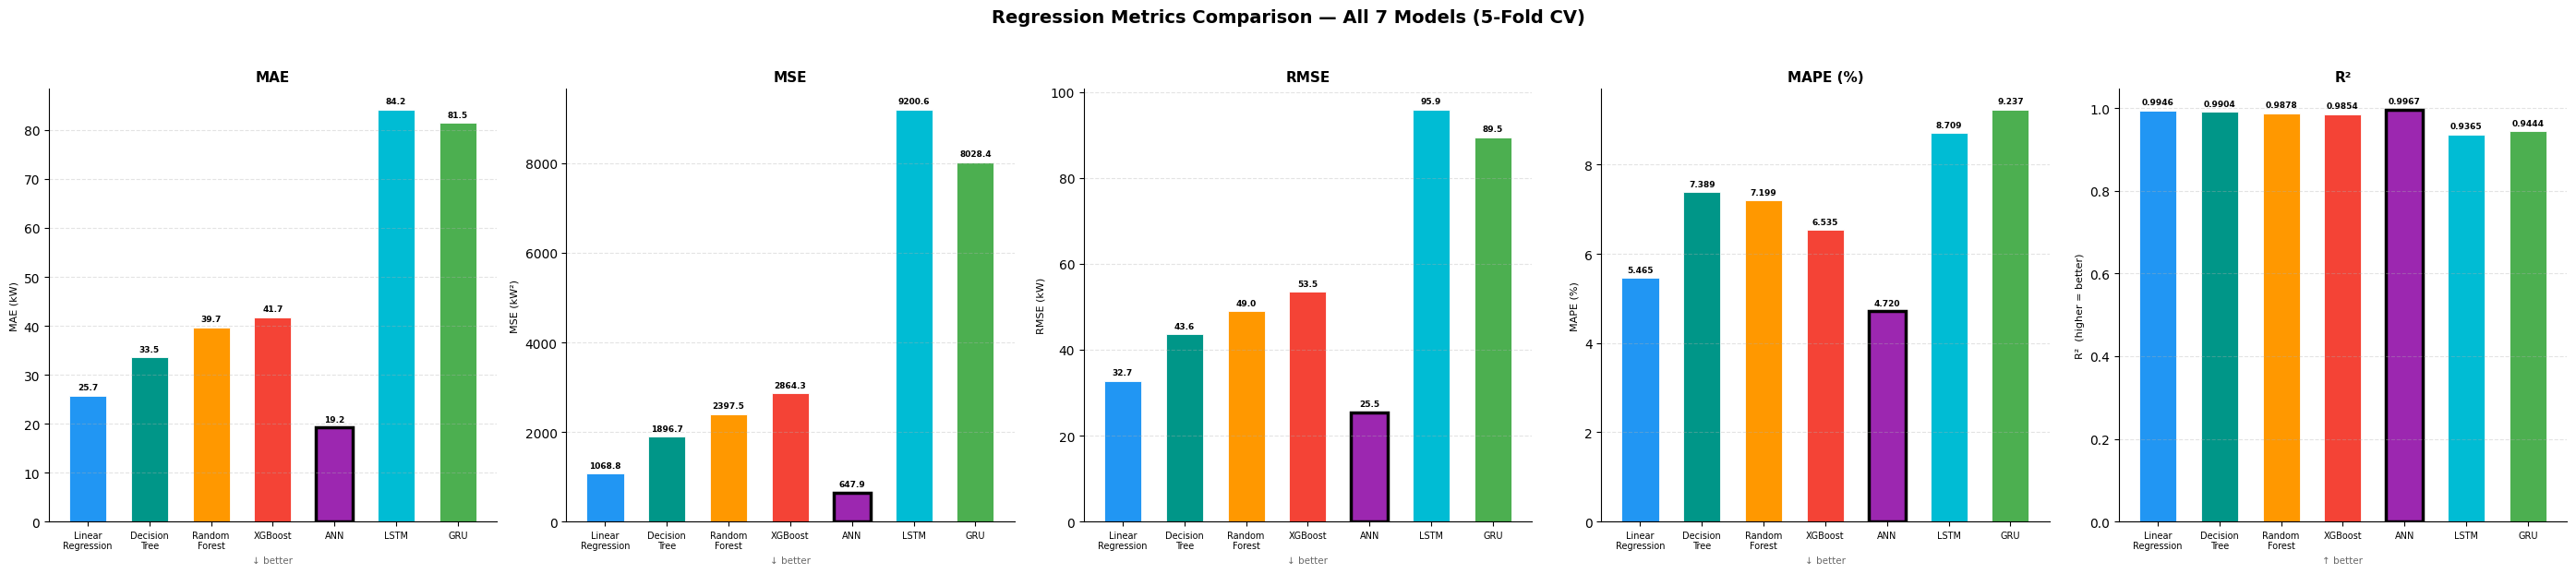

Saved → cmp_01_regression_metrics.png


In [5]:
metrics_cfg = [
    ('MAE',      'MAE (kW)',               False),
    ('MSE',      'MSE (kW²)',              False),
    ('RMSE',     'RMSE (kW)',              False),
    ('MAPE (%)', 'MAPE (%)',               False),
    ('R²',       'R²  (higher = better)',  True ),
]

fig, axes = plt.subplots(1, 5, figsize=(28, 6))
fig.suptitle('Regression Metrics Comparison — All 7 Models (5-Fold CV)',
             fontsize=14, fontweight='bold', y=1.03)

models  = reg_df['Model'].tolist()
colors  = [MODEL_COLORS[m] for m in models]
x       = np.arange(len(models))

for ax, (col, ylabel, higher_better) in zip(axes, metrics_cfg):
    vals = reg_df[col].values
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.6, width=0.6)
    best_idx = int(np.argmax(vals)) if higher_better else int(np.argmin(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.4f}' if col == 'R²' else (f'{val:.3f}' if col == 'MAPE (%)' else f'{val:.1f}')
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                fmt, ha='center', va='bottom', fontsize=6.5, fontweight='bold')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ','\n') for m in models], fontsize=7)
    ax.set_xlabel('↑ better' if higher_better else '↓ better', fontsize=7.5, color='dimgray')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('cmp_01_regression_metrics.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → cmp_01_regression_metrics.png')


## Section 6 — Accuracy & Weighted F1-Score Bar Charts

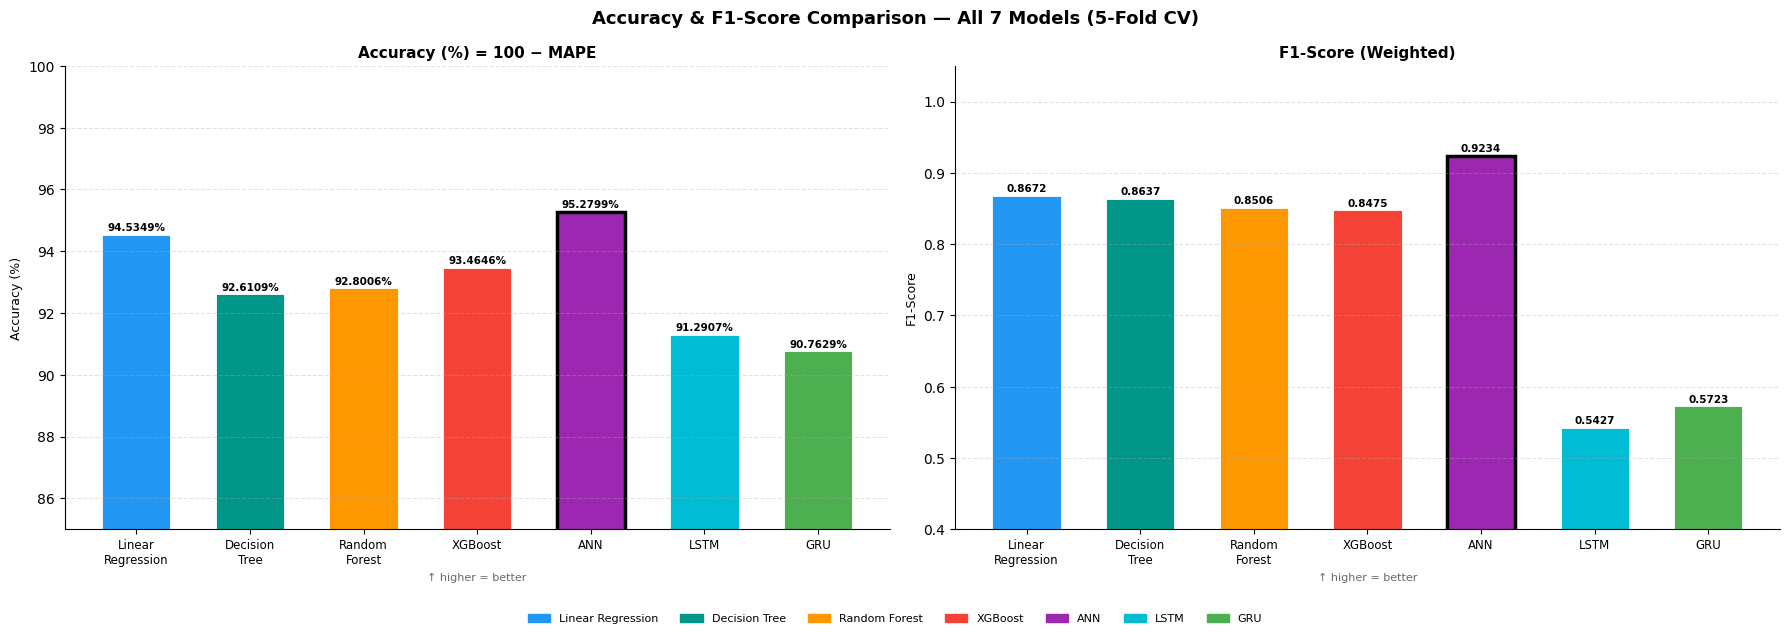

Saved → cmp_02_accuracy_f1.png


In [6]:
models_cls = cls_df['Model'].tolist()
colors_cls = [MODEL_COLORS[m] for m in models_cls]
x          = np.arange(len(models_cls))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Accuracy & F1-Score Comparison — All 7 Models (5-Fold CV)',
             fontsize=13, fontweight='bold')

# ── Accuracy ────────────────────────────────────────────────────────────────
ax   = axes[0]
vals = cls_df['Accuracy (%)'].values
bars = ax.bar(x, vals, color=colors_cls, edgecolor='white', linewidth=0.6, width=0.6)
best = int(np.argmax(vals))
bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.06,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.set_title('Accuracy (%) = 100 − MAPE', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ','\n') for m in models_cls], fontsize=8.5)
ax.set_ylim(85, 100)
ax.set_xlabel('↑ higher = better', fontsize=8, color='dimgray')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)

# ── Weighted F1 ─────────────────────────────────────────────────────────────
ax   = axes[1]
vals = cls_df['F1 (weighted)'].values
bars = ax.bar(x, vals, color=colors_cls, edgecolor='white', linewidth=0.6, width=0.6)
best = int(np.argmax(vals))
bars[best].set_edgecolor('black'); bars[best].set_linewidth(2.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax.set_title('F1-Score (Weighted)', fontsize=11, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ','\n') for m in models_cls], fontsize=8.5)
ax.set_ylim(0.40, 1.05)
ax.set_xlabel('↑ higher = better', fontsize=8, color='dimgray')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)

handles = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MODEL_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=8,
           bbox_to_anchor=(0.5, -0.06), frameon=False)
plt.tight_layout()
plt.savefig('cmp_02_accuracy_f1.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → cmp_02_accuracy_f1.png')


## Section 7 — Per-Class F1-Score Grouped Bar Chart

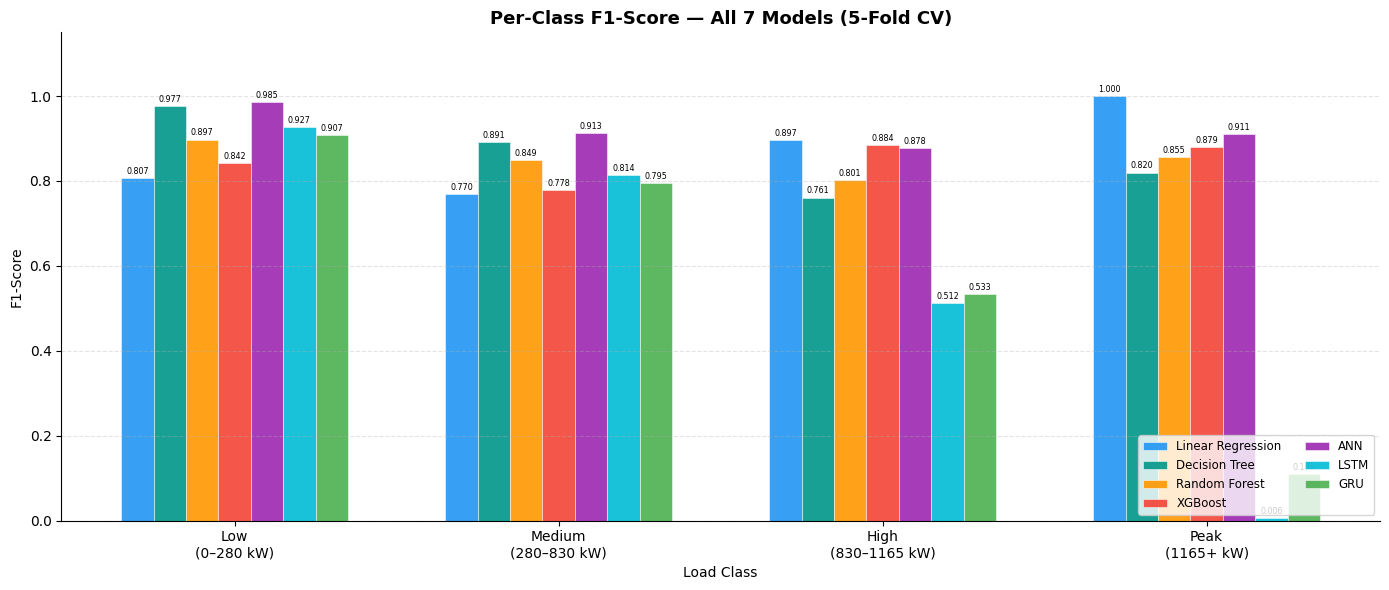

Saved → cmp_03_f1_per_class.png


In [7]:
class_labels = ['Low\n(0–280 kW)', 'Medium\n(280–830 kW)',
                 'High\n(830–1165 kW)', 'Peak\n(1165+ kW)']
f1_cols  = ['F1_Low', 'F1_Medium', 'F1_High', 'F1_Peak']
f1_data  = cls_df[f1_cols].values
n_models  = len(models_cls)
x2        = np.arange(4)
w2        = 0.10
half      = (n_models - 1) / 2
offsets   = [(i - half) * w2 for i in range(n_models)]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (mname, color) in enumerate(zip(models_cls, colors_cls)):
    bs = ax.bar(x2 + offsets[i], f1_data[i], width=w2,
                color=color, edgecolor='white', linewidth=0.4,
                label=mname, alpha=0.90)
    for bar, val in zip(bs, f1_data[i]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=5.8)

ax.set_title('Per-Class F1-Score — All 7 Models (5-Fold CV)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_xlabel('Load Class', fontsize=10)
ax.set_xticks(x2)
ax.set_xticklabels(class_labels, fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8.5, loc='lower right', ncol=2)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('cmp_03_f1_per_class.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → cmp_03_f1_per_class.png')


## Section 8 — Overall Score Radar Chart

Each axis normalised 0–1 (higher = better). Error metrics inverted so smaller error → higher score.

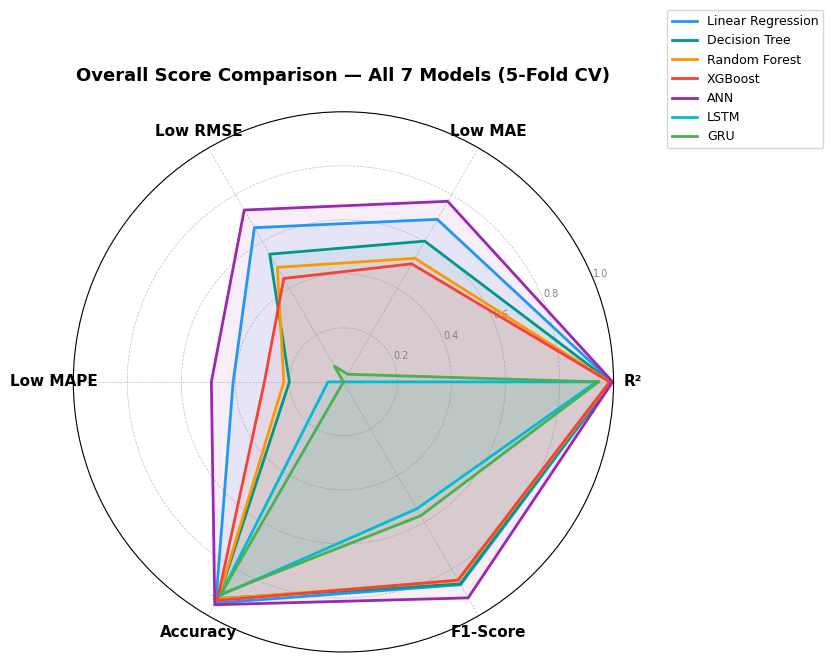

Saved → cmp_04_radar.png


In [8]:
radar_data = pd.DataFrame({
    'Model':    reg_df['Model'].tolist(),
    'R²':       reg_df['R²'].values,
    '1-MAE_n':  1 - (reg_df['MAE'].values   / reg_df['MAE'].max()),
    '1-RMSE_n': 1 - (reg_df['RMSE'].values  / reg_df['RMSE'].max()),
    '1-MAPE_n': 1 - (reg_df['MAPE (%)'].values / reg_df['MAPE (%)'].max()),
    'Accuracy': cls_df['Accuracy (%)'].values / 100,
    'F1':       cls_df['F1 (weighted)'].values,
})

categories = ['R²', 'Low MAE', 'Low RMSE', 'Low MAPE', 'Accuracy', 'F1-Score']
score_cols = ['R²', '1-MAE_n', '1-RMSE_n', '1-MAPE_n', 'Accuracy', 'F1']
N      = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for _, row in radar_data.iterrows():
    model  = row['Model']
    values = [row[c] for c in score_cols] + [row[score_cols[0]]]
    color  = MODEL_COLORS[model]
    ax.plot(angles, values, color=color, linewidth=2, label=model)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7, color='grey')
ax.set_title('Overall Score Comparison — All 7 Models (5-Fold CV)',
             fontsize=13, fontweight='bold', pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.40, 1.20), fontsize=9)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig('cmp_04_radar.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → cmp_04_radar.png')


## Section 9 — Combined Performance Heatmap

Green = better, Red = worse. Each column normalised independently 0–1.

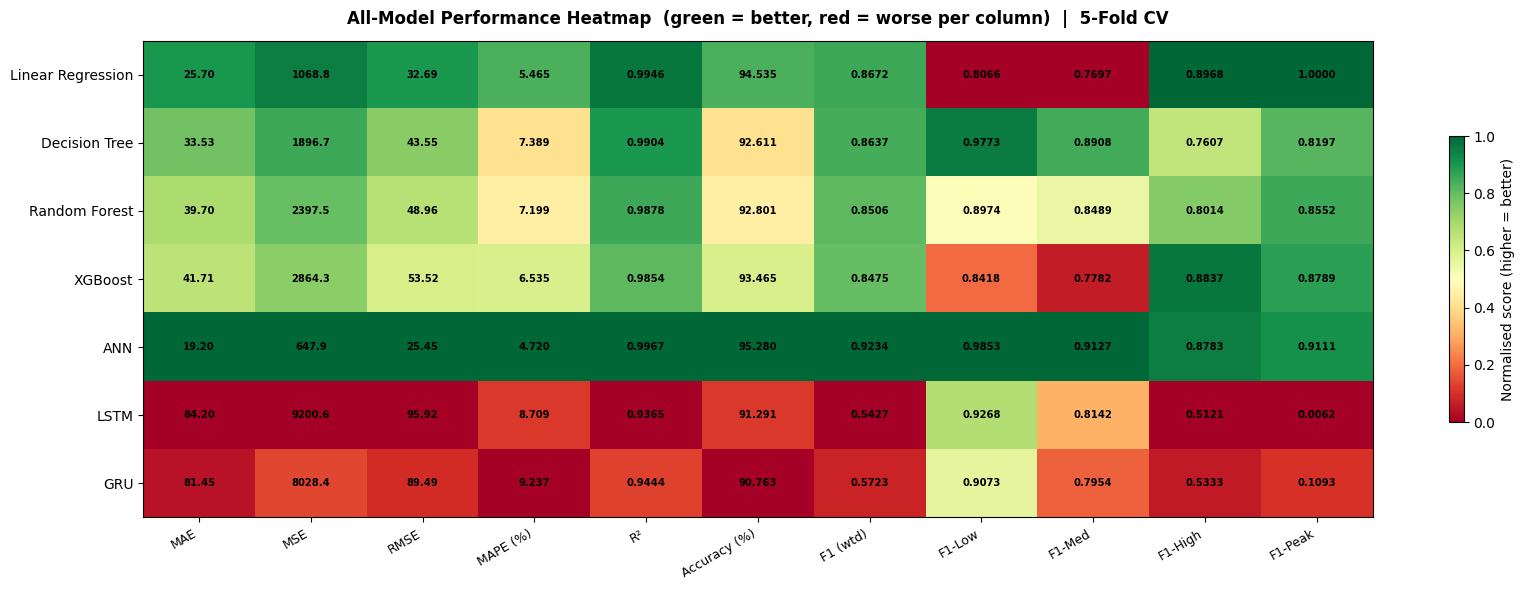

Saved → cmp_05_heatmap.png


In [9]:
summary = pd.DataFrame({
    'Model':        reg_df['Model'],
    'MAE':          reg_df['MAE'],
    'MSE':          reg_df['MSE'],
    'RMSE':         reg_df['RMSE'],
    'MAPE (%)':     reg_df['MAPE (%)'],
    'R²':           reg_df['R²'],
    'Accuracy (%)': cls_df['Accuracy (%)'],
    'F1 (wtd)':     cls_df['F1 (weighted)'],
    'F1-Low':       cls_df['F1_Low'],
    'F1-Med':       cls_df['F1_Medium'],
    'F1-High':      cls_df['F1_High'],
    'F1-Peak':      cls_df['F1_Peak'],
}).set_index('Model')

lower_better = ['MAE', 'MSE', 'RMSE', 'MAPE (%)']
norm_df = summary.copy().astype(float)
for col in norm_df.columns:
    mn, mx = norm_df[col].min(), norm_df[col].max()
    if mx == mn:
        norm_df[col] = 0.5
    elif col in lower_better:
        norm_df[col] = 1 - (norm_df[col] - mn) / (mx - mn)
    else:
        norm_df[col] = (norm_df[col] - mn) / (mx - mn)

fig, ax = plt.subplots(figsize=(17, 6))
im = ax.imshow(norm_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(summary.columns)))
ax.set_xticklabels(summary.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(summary.index)))
ax.set_yticklabels(summary.index, fontsize=10)

for i in range(len(summary.index)):
    for j, col in enumerate(summary.columns):
        val = summary.iloc[i, j]
        if col in ['MAE','RMSE']:               fmt = f'{val:.2f}'
        elif col == 'MSE':                      fmt = f'{val:.1f}'
        elif col in ['MAPE (%)','Accuracy (%)']: fmt = f'{val:.3f}'
        else:                                   fmt = f'{val:.4f}'
        ax.text(j, i, fmt, ha='center', va='center',
                fontsize=7.2, color='black', fontweight='bold')

ax.set_title(
    'All-Model Performance Heatmap  (green = better, red = worse per column)  |  5-Fold CV',
    fontsize=12, fontweight='bold', pad=12)
plt.colorbar(im, ax=ax, shrink=0.6, label='Normalised score (higher = better)')
plt.tight_layout()
plt.savefig('cmp_05_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → cmp_05_heatmap.png')


## Section 10 — Individual Actual vs Predicted Scatter Plots

Loads the scatter `.png` files saved by each source notebook.
Run the source notebooks first, then re-run this cell.

| Model | File saved by source notebook |
|-------|------------------------------|
| Linear Regression | `scatter_linear_regression.png` |
| Decision Tree | `scatter_decision_tree.png` |
| Random Forest | `scatter_random_forest.png` |
| XGBoost | `scatter_xgboost.png` |
| ANN | `scatter_ann_kfold.png` |
| LSTM | `scatter_lstm_fixed.png` |
| GRU | `scatter_gru.png` |


In [10]:
scatter_files = {
    'Linear Regression': 'scatter_linear_regression.png',
    'Decision Tree':     'scatter_decision_tree.png',
    'Random Forest':     'scatter_random_forest.png',
    'XGBoost':           'scatter_xgboost.png',
    'ANN':               'scatter_ann_kfold.png',
    'LSTM':              'scatter_lstm_fixed.png',
    'GRU':               'scatter_gru.png',
}

available = {m: f for m, f in scatter_files.items() if os.path.exists(f)}
missing   = [m for m in scatter_files if m not in available]
print(f'Scatter PNGs found   : {list(available.keys())}')
print(f'Scatter PNGs missing : {missing}')

if available:
    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(7*n, 7))
    if n == 1: axes = [axes]
    for ax, (model, fname) in zip(axes, available.items()):
        img = mpimg.imread(fname)
        ax.imshow(img); ax.axis('off')
        ax.set_title(model, fontsize=11, fontweight='bold', pad=6)
    fig.suptitle('Actual vs Predicted — Individual Scatter Plots',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cmp_06_scatter_individual.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → cmp_06_scatter_individual.png')
else:
    print('No scatter PNGs found — run source notebooks first.')


Scatter PNGs found   : []
Scatter PNGs missing : ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'ANN', 'LSTM', 'GRU']
No scatter PNGs found — run source notebooks first.


## Section 11 — Combined 2×4 Scatter Grid

Displays scatter PNGs if available, otherwise shows a metric scorecard panel.

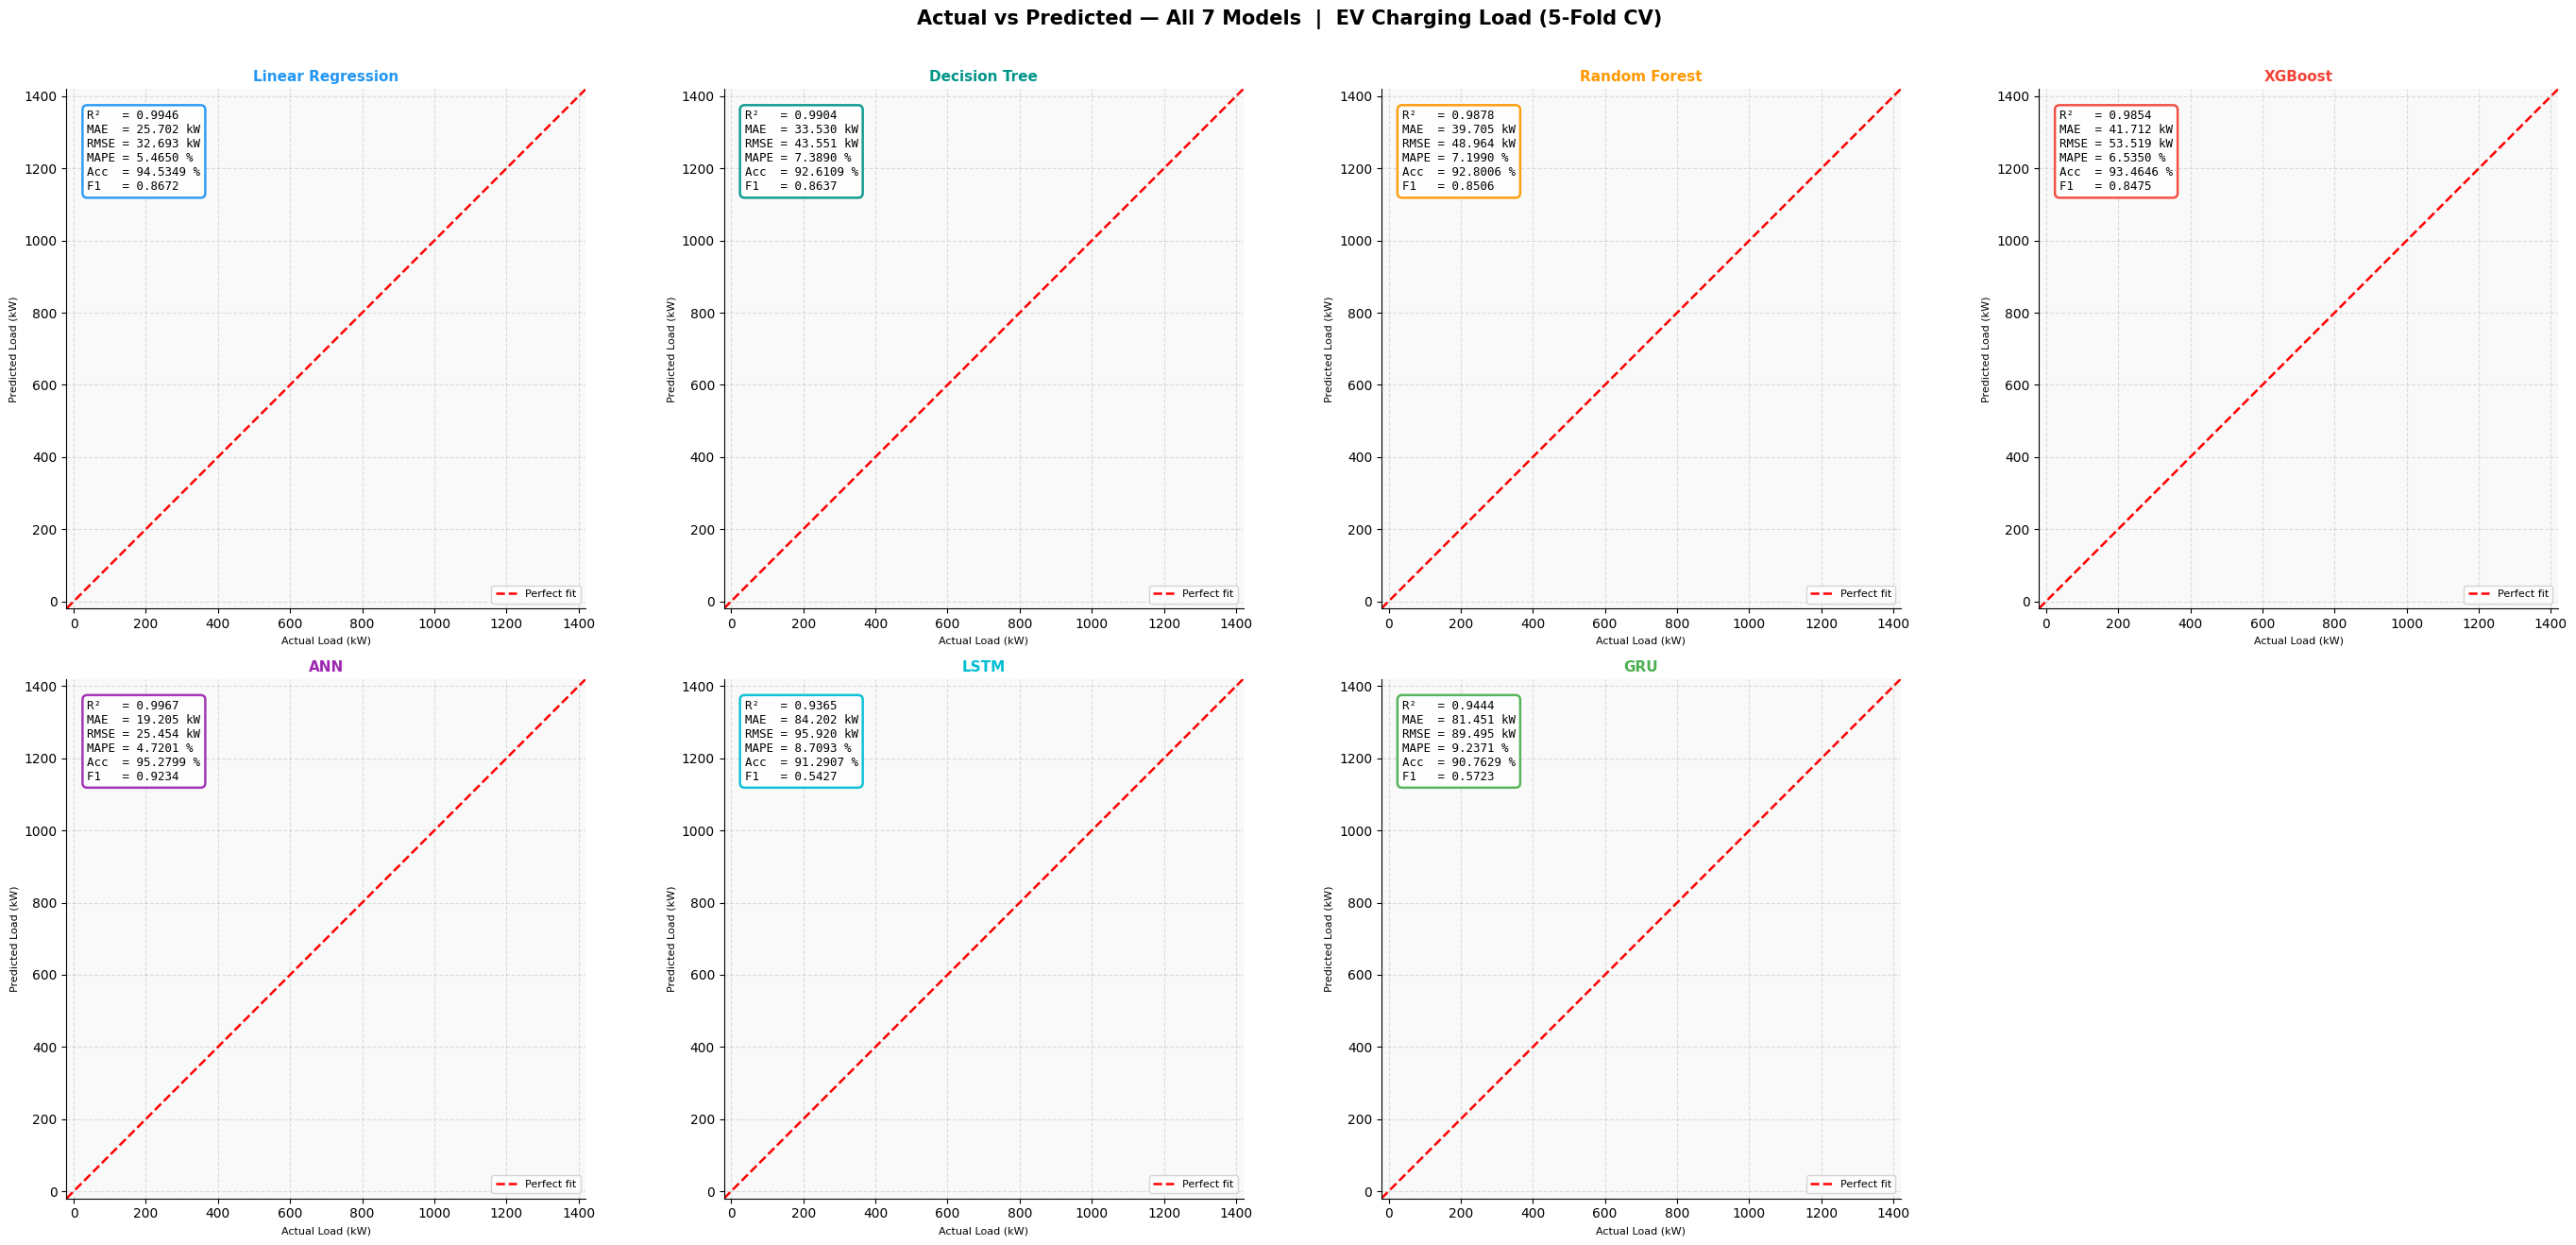

Saved → cmp_07_scatter_grid.png


In [11]:
# Metric scorecard lookup (from hardcoded data above)
metrics_lookup = {}
for _, r in reg_df.iterrows():
    m = r['Model']
    acc_val = cls_df.loc[cls_df['Model'] == m, 'Accuracy (%)'].values[0]
    f1_val  = cls_df.loc[cls_df['Model'] == m, 'F1 (weighted)'].values[0]
    metrics_lookup[m] = dict(r2=r['R²'], mae=r['MAE'], rmse=r['RMSE'],
                              mape=r['MAPE (%)'], acc=acc_val, f1=f1_val)

fig, axes = plt.subplots(2, 4, figsize=(28, 13))
fig.suptitle('Actual vs Predicted — All 7 Models  |  EV Charging Load (5-Fold CV)',
             fontsize=15, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for idx, model in enumerate(MODEL_ORDER):
    ax    = axes_flat[idx]
    color = MODEL_COLORS[model]
    mt    = metrics_lookup[model]
    fname = scatter_files.get(model, '')

    if os.path.exists(fname):
        img = mpimg.imread(fname)
        ax.imshow(img); ax.axis('off')
        ax.set_title(model, fontsize=11, fontweight='bold', color=color, pad=6)
    else:
        lims = [-20, 1420]
        ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect fit')
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
        ax.set_title(f'{model}', fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Actual Load (kW)', fontsize=8)
        ax.set_ylabel('Predicted Load (kW)', fontsize=8)
        ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines[['top','right']].set_visible(False)
        ax.set_facecolor('#f9f9f9')
        txt = (f"R²   = {mt['r2']:.4f}\n"
               f"MAE  = {mt['mae']:.3f} kW\n"
               f"RMSE = {mt['rmse']:.3f} kW\n"
               f"MAPE = {mt['mape']:.4f} %\n"
               f"Acc  = {mt['acc']:.4f} %\n"
               f"F1   = {mt['f1']:.4f}")
        ax.text(0.04, 0.96, txt, transform=ax.transAxes,
                fontsize=9, va='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor=color, linewidth=1.8, alpha=0.93))

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig('cmp_07_scatter_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → cmp_07_scatter_grid.png')


## Section 12 — Download All Figures

Run in Google Colab to download every comparison figure.

In [12]:
try:
    from google.colab import files
    figures = [
        'cmp_01_regression_metrics.png',
        'cmp_02_accuracy_f1.png',
        'cmp_03_f1_per_class.png',
        'cmp_04_radar.png',
        'cmp_05_heatmap.png',
        'cmp_06_scatter_individual.png',
        'cmp_07_scatter_grid.png',
    ]
    for f in figures:
        if os.path.exists(f):
            files.download(f)
            print(f'Downloaded → {f}')
        else:
            print(f'Skipped (not found) → {f}')
    print('\nAll available downloads complete ✓')
except ImportError:
    import glob
    print('Not in Colab — files saved locally:')
    for f in sorted(glob.glob('cmp_*.png')):
        print(f'  {f}')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → cmp_01_regression_metrics.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded → cmp_05_heatmap.png
Skipped (not found) → cmp_06_scatter_individual.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded → cmp_07_scatter_grid.png

All available downloads complete ✓
